## <span style="color:blue"> Lezione 8 </span>



In [54]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

import numpy as np

parent_folder="l_08_all_es/OUTPUT/"


### Ricerca ground state di un'Hamiltoniana: metodi variazionali 

Dato un sistema retto dall'hamiltoniana $\hat{H}(\vec{x},\vec{p})$, ne si vuole trovare il ground state, ossia la funzione d'onda $\phi(\vec{x})$ che minimizza $$\langle\hat{H} \rangle _{\phi}= \int \mathrm{d}  \vec{x}  \ \phi^*(\vec{x})\hat{H}(\vec{x} ,\vec{p} ) \phi(\vec{x}).$$ 

Il problema raramente è risolvibile esattamente, ma può essere affrontato con metodi variazionali.
Si considera la funzione di prova $ \psi_{\vec{a}}^T(x) $
e si cercano i parametri $\vec{a}$ che minimizzano $\langle\hat{H} \rangle _{\vec{a}} := \langle\hat{H} \rangle _{\psi_{\vec{a}}^T}$. La funzione così trovata sarà quindi un'approssimazione della funzione d'onda di ground state e $\langle\hat{H} \rangle _{\vec{a}} $ sarà un'approssimazione dell'energia di ground state $E_0$, con quest'ultima come lower bound. 

La ricerca dei parametri che minimizzano una quantità è un problema di ottimizzazione. Essi sono una classe di problemi molto vasta ed esistono numerosi tipi di algoritmi volti alla sua risoluzione. È stato scelto l'algoritmo di _simulated annealing_. 

### Simulated annealing

Si ispira al processo naturale del raffreddamento lento di un sistema e fa quindi parte dei cosidetti _algoritmi metauristici_. 

Si interpreta la quantità da minimizzare $L(\vec{a})$ (dove $\vec{a}$ sono i parametri da ottimizzare) come l'espressione dell' "energia" del sistema e si
considera la distribuzione di Boltzmann: $$p(\vec{a})= \frac{ \exp(-\beta L(\vec{a}))}{Z}.$$ $T=1/\beta$ è la "temperatura" del sistema e ha le dimensioni dell'inverso di $L(\vec{a})$. L'algoritmo consiste nel campionare $p(\vec{a})$ con $\beta$ variabile nel tempo , tramite un _annealing schedule_. In particolare, partendo da una configurazione $\vec{a}_0$, l'algoritmo: 
1. Effettua $n_1$ campionamenti di $p(\vec{a})$ alla temperatura $1/\beta_1$, terminando nella configurazione $\vec{a}_1$.
2. Partendo da $\vec{a}_1$, effettua $n_2$ campionamenti di $p(\vec{a})$ alla temperatura $1/\beta_2$ , terminando nella configurazione $\vec{a}_2$.
3. Partendo da $\vec{a}_2$...

Dopo $B$ passi, il sistema si troverà nella configurazione finale $\vec{a}_B$. Se il "raffreddamento" è stato sufficientemente lento, la configurazione finale si troverà in una zona ragionevolmente vicina al minimo di $L(\vec{a})$. 

Il campionamento di $p(\vec{a})$, a temperatura fissata $1/\beta$ può essere effettuato tramite l'algoritmo di Metropolis: si genera una nuova configurazione $\vec{b}$ come proposta di mossa, e si accetta la mossa con probabilità: $$A=\min\left[1, \frac{\exp(-\beta(L(\vec{b})))}{\exp(-\beta(L(\vec{a})))} \right].$$





Si esamina il caso specifico monodimensionale $ \hat{H}=\frac{p^2}{2m} + V(x)$, $V(x)=x^4 - \frac{5}{2} x^2 $, per cui esiste una soluzione analitica al problema. Essa è implementata nella cella sottostante e servirà come confronto per i risultati della simulazione. 

In [55]:
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

#Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
#plt.figure(figsize=(8,5))
#scale = 0.3
#plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
#plt.plot(x,(psi[0])**2)
#plt.plot(x,(psi[1])**2)
#plt.plot(x,(psi[2])**2)
#plt.title("Potential & Probabilities")
#plt.xlabel("x")
#plt.grid(True)
#plt.xlim((-3,3))
#plt.ylim((-0.6,0.6))
#plt.show()


Ground state energy:  -0.4604658796927152
1st excited state energy:  0.0974247133176099
2nd excited state energy:  1.9717331343930193



Come funzione di prova, si considera $ \psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}} $. 
Si cercano quindi i parametri $\mu > 0$ e $\sigma >0$ (per simmetria) che minimizzano $\langle\hat{H} \rangle _{\sigma,\mu} := \langle\hat{H} \rangle _{\psi_{\sigma,\mu}}$. 

Si riscrive: 
$$ \langle\hat{H} \rangle _{\sigma, \mu} = \int \mathrm{d} x |\psi_{\sigma,\mu}(x)|^2 \frac{ \hat{H} \psi_{\sigma,\mu}(x) }{\psi_{\sigma,\mu}(x)} $$
e lo si calcola col metodo Monte Carlo. 

$|\psi_{\sigma, \mu}(x)|^2$ viene campionata tramite un'ulteriore applicazione dell'algoritmo di Metropolis. La proposta di mossa è $x_{\mathrm{new}}= x + \delta_{\mathrm{in}} u$, con $u$ estratto uniformemente dall'intervallo $[-1,1)$ e $\delta_{\mathrm{in}}$ un parametro. La probabilità di accettazione risulta $$p_{\mathrm{in}} = \min \left[1, \frac{|\psi_{\sigma,\mu}(x_{\mathrm{new}})|^2}{|\psi_{\sigma,\mu}(x)|^2}\right]$$ 

Per le $x$ campionate (trascorsi $N_e$ step di equilibrazione), suddivise in $N_{\mathrm{blocks}}$ di $N_{\mathrm{steps}}$, si calcola la quantità: $$ \frac{ \hat{H} \psi_{\sigma,\mu}(x) }{\psi_{\sigma,\mu}(x)}= - \frac{x^2+\mu^2}{2 \sigma^4} + \frac{1}{2 \sigma^2} + \frac{\mu x}{\sigma^4} \tanh \left( \frac{\mu x}{\sigma^2}\right) + V(x)$$ e la si media applicando la tecnica del data blocking. 


Come legge di raffreddamento, si è scelta $T_j=\alpha T_{j-1}$, dove $\alpha \in (0,1)$ è detto _cooling factor_. 

Per ogni $\beta_i = 1/T_i$ fissato, si eseguono $R$ step Metropolis, con proposta di mossa: $\sigma_{\mathrm{new}}= \sigma + \delta_{\mathrm{out}} u_1$, $\mu_{\mathrm{new}}= \mu + \delta_{\mathrm{out}} u_2$ ( $u_1$,$u_2$  estratti uniformemente dall'intervallo $[-1,1)$ e $\delta_{\mathrm{out}}$ parametro ).


### <span style="color:DodgerBlue"> Esercizio 8.2 </span>



La simulazione è stata effettuata con i seguenti parametri: 


- $N_{\mathrm{blocks}}= 100 $ blocchi.
- $N_{\mathrm{steps}}= 2000 $ step per blocco.
- $N_{e}= 200$ step di equilibrazione per il Metropolis del calcolo dell'integrale.
- _cooling factor_ $\alpha=0.85$.
- $B=60$ valori di $\beta$.
- $R=20$ step Metropolis per ogni $\beta$.
- $\delta_{\mathrm{out}}= 0.5 $ per il Metropolis del _simulated annealing_.
- $\delta_{\mathrm{in}}= 2.3 $  per il Metropolis del calcolo dell'integrale.

Come valori iniziali, si sono scelti: 

- Temperatura iniziale $T_0=2.0$ 
- Parametri di partenza: $\sigma_0=1.0$ e $\mu_0 =1.5$ 
- Punto di partenza per il Metropolis del calcolo dell'integrale: $x_0=0.0$ 


Il parametro $\delta_{\mathrm{out}}$ viene automaticamente aggiustato durante la simulazione di modo da cercare di tenere l'accettanza del Metropolis all'incirca al 50%: se l'accettanza scende sotto il $40\%$, viene diviso per $3$; se sale sopra il $60\%$ viene duplicato$. Superato il $90\%$ di $B$, il parametro $R$ viene moltiplicato per due.

Nella cella sottostante vengono caricati i valori di $\beta$, e i valori di $\sigma,\mu$  e  $\langle\hat{H} \rangle _{\sigma,\mu} $ col suo errore per ogni step Metropolis. 

In [56]:
beta=np.loadtxt(f"{parent_folder}Main_results.csv",delimiter=",",usecols=1,skiprows=1) #caricamento beta dal file principale
T=1/beta

B=len(beta)


#caricamento da file secondari

sigma=[]
mu=[]
avg_H=[]
avg_H_err=[]

for i in range(B):

    filename=f"{parent_folder}DETAIL/" + str(i)+".csv"

    data=np.loadtxt(filename,delimiter=",",usecols=(0,1,2,3),skiprows=1)
    data = np.atleast_2d(data)
    sigma.append(data[:,0])
    mu.append(data[:,1])
    avg_H.append(data[:,2])
    avg_H_err.append(data[:,3])








In [57]:

#numero di step metropolis per ogni beta
R=np.array([len(s) for s in sigma]) 
Max_step=R.sum()
steps=np.arange(1,Max_step+1)#steps non divisi per beta
split_steps = np.split(steps, np.cumsum(R)[:-1]) #step divisi per beta (per applicare color map indicante la temperatura)

#sigma e mu non divisi, per traiettoria in spazio parametri
all_sigma=np.concat([s for s in sigma])
all_mu=np.concat([m for m in mu])

#color map, per segnare l'andamento della temperatura
cmap = plt.get_cmap('plasma_r')
norm = colors.Normalize(vmin=0, vmax=B-1)

La cella sottostante grafica $\langle\hat{H} \rangle _{\sigma,\mu} $ in funzione del numero di step Metropolis. La scala di colore indica l'abbassamento della temperatura.

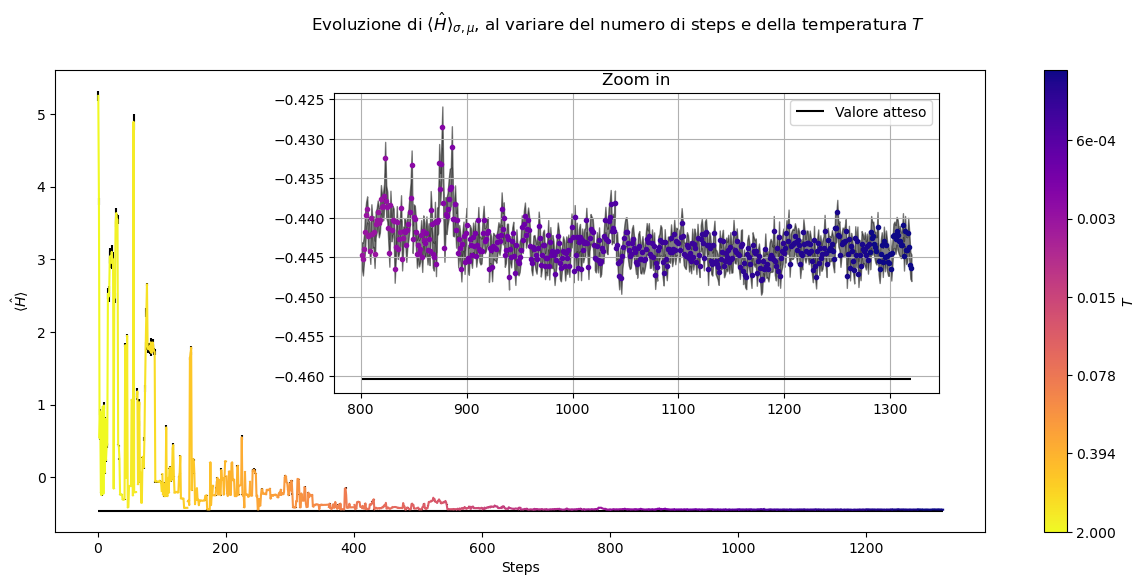

In [58]:
fig,ax=plt.subplots(1,1,figsize=[15,6])


#zoom (per focalizzare sulle basse temperature)
ax_ins = ax.inset_axes([0.3, 0.3, 0.65, 0.65])
zoom_in_index=40


for i in range(B):
    color = cmap(norm(i))
    ax.errorbar(split_steps[i],avg_H[i],yerr=avg_H_err[i],color=color,ecolor="black")
    if (i>=zoom_in_index):
        ax_ins.plot(split_steps[i],avg_H[i],".",color=color)
        ax_ins.fill_between(split_steps[i],avg_H[i]-avg_H_err[i], avg_H[i]+avg_H_err[i],alpha=0.5, color="black")



ax_ins.set_title("Zoom in")

ax.hlines(E[0],0,steps[-1],color="black",label="Valore atteso")
ax_ins.hlines(E[0],split_steps[zoom_in_index][0],steps[-1],color="black",label="Valore atteso")
ax_ins.legend()


ax_ins.grid()
ax.set_xlabel("Steps")
ax.set_ylabel(r"$\langle\hat{H} \rangle $")


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar=fig.colorbar(sm, ax=ax, label=r'$T$')
ticks=cbar.get_ticks()

selected_T = T[ticks[:-1].astype(int)]
labels = [f"{val:.0e}" if val < 0.001 else f"{val:.3f}" for val in selected_T]
#labels = [ f"{val:.4f}" for val in selected_T]

cbar.set_ticks(ticks=ticks[:-1],labels=labels)

fig.suptitle(r"Evoluzione di $\langle\hat{H} \rangle_{\sigma,\mu}$, al variare del numero di steps e della temperatura $T$");




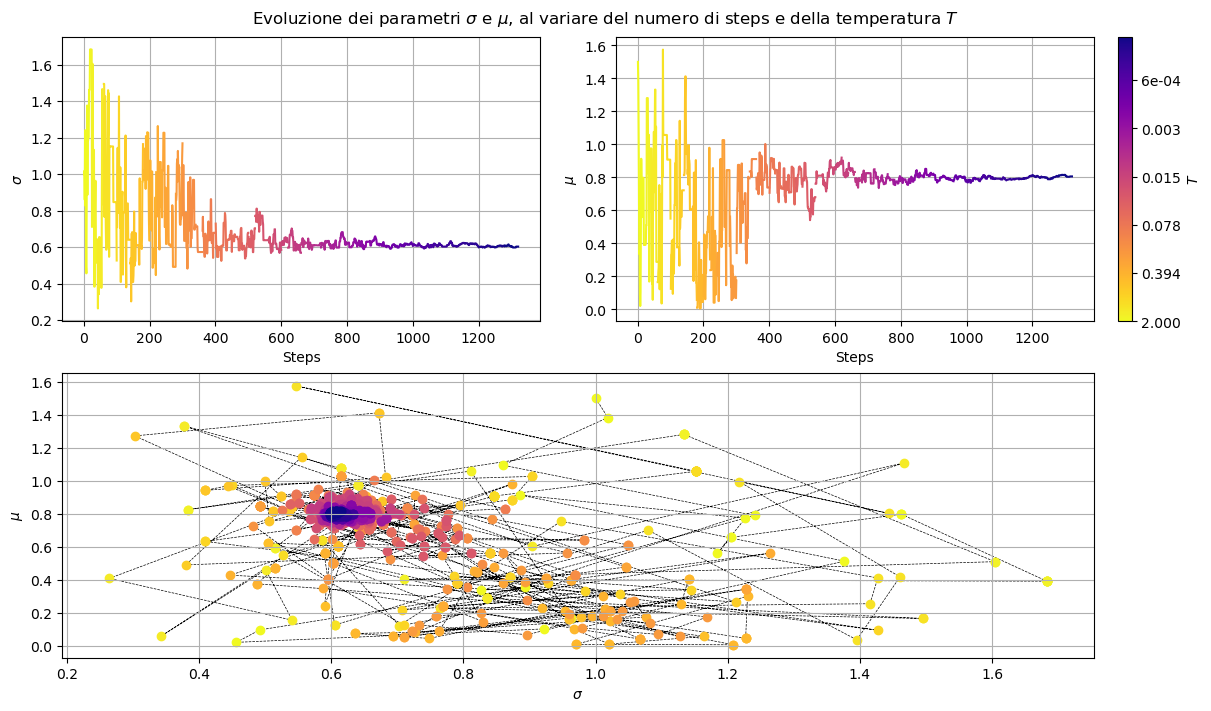

In [59]:


fig, axs = plt.subplot_mosaic([['top left', 'top right'],['bottom', 'bottom']], figsize=(12, 7), constrained_layout=True) 


axs["bottom"].plot(all_sigma,all_mu,color="black",ls="--",lw=0.5,zorder=-1)



for i in range(B):
    color = cmap(norm(i))
    axs["top left"].plot(split_steps[i],sigma[i],color=color)
    axs["top right"].plot(split_steps[i],mu[i],color=color)
    axs["bottom"].scatter(sigma[i],mu[i],color=color,zorder=1)



axs["top left"].grid()
axs["top right"].grid()
axs["bottom"].grid()


axs["top left"].set_xlabel(r"Steps")
axs["top right"].set_xlabel(r"Steps")

axs["top left"].set_ylabel(r"$\sigma $")
axs["top right"].set_ylabel(r"$\mu $")

axs["bottom"].set_xlabel(r"$\sigma $")
axs["bottom"].set_ylabel(r"$\mu $")


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar=fig.colorbar(sm, ax=axs["top right"], label=r'$T$')
ticks=cbar.get_ticks()

cbar.set_ticks(ticks=ticks[:-1],labels=labels)

fig.suptitle(r"Evoluzione dei parametri $\sigma$ e $\mu$, al variare del numero di steps e della temperatura $T$");



Per i parametri $\sigma,\mu$ che la simulazione ha indicato come ottimali, si sono stampati nel dettaglio la distribuzione di $N_{\mathrm{blocks}}N_{\mathrm{steps}}$ valori di $x$ secondo $|\psi_{\sigma,\mu}(x)|^2$ e il valore di $\langle\hat{H}\rangle_{\sigma,\mu} $  in funzione di $N_{\mathrm{blocks}}$. 

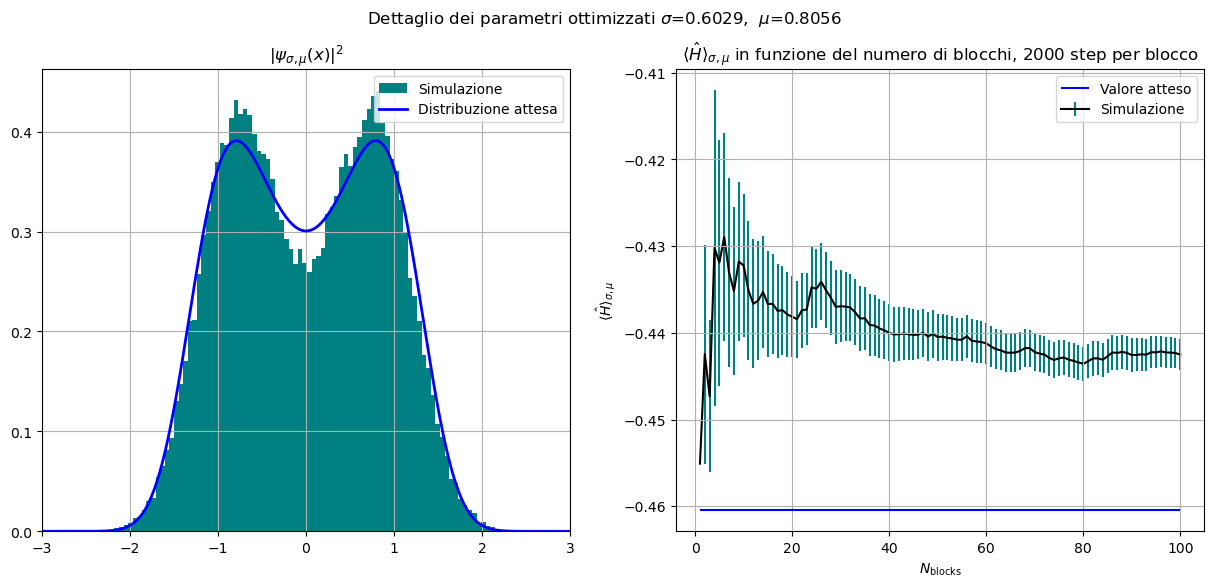

In [60]:

#caricamento dati
x_dist=np.loadtxt(f"{parent_folder}x_dist.dat")
integral,error=np.loadtxt(f"{parent_folder}integral.dat",usecols=(2,3),unpack=True,skiprows=1)
blocks=np.arange(1,len(integral)+1)

fig,axs=plt.subplots(1,2,figsize=[15,6])


#grafico 1: distribuzione x
axs[0].hist(x_dist,100,color="teal",density=True,label="Simulazione")
axs[0].plot(x,(psi[0])**2,color="blue",lw=2.0, label="Distribuzione attesa")
axs[0].grid()
axs[0].set_xlim(-3,3)
axs[0].set_title(r"$|\psi_{\sigma,\mu}(x)|^2$")
axs[0].legend()

#grafico 2: integrale
axs[1].errorbar(blocks,integral,error,color="black",ecolor="teal",label="Simulazione",zorder=-1)
axs[1].hlines(E[0] ,blocks[0],blocks[-1],color="blue",label="Valore atteso")
axs[1].legend()
axs[1].grid()
axs[1].set_ylabel(r"$\langle\hat{H} \rangle_{\sigma,\mu}$")
axs[1].set_xlabel(r"$N_{\mathrm{blocks}}$")
axs[1].set_title(r"$\langle\hat{H}\rangle_{\sigma,\mu} $ in funzione del numero di blocchi, $2000$ step per blocco")


fig.suptitle(rf"Dettaglio dei parametri ottimizzati $\sigma$={sigma[-1][-1]:.4f},  $\mu$={mu[-1][-1]:.4f}"); 





Le soluzioni trovate non coincidono con quelle esatte, ma ci si avvicinano. Ciò, per una vasta gamma di applicazioni, è considerato sufficiente. 